# 03 — TCO Breakdown Analysis

This notebook runs a single simulation and visualizes the TCO breakdown
by cost category (CapEx vs OpEx), server fleet composition, and stranded power.

In [1]:
import sys
sys.path.insert(0, '..')

from dc_tco.config import load_config
from dc_tco.simulation import run_simulation
from dc_tco.plotting import (
    plot_tco_breakdown,
    plot_server_timeline,
    plot_stranded_power,
    plot_demand_curve,
)

In [2]:
cfg = load_config('../configs/default.yaml')
result = run_simulation(cfg)

print(f'Total TCO: ${result.total_tco / 1e9:.3f} B')
print(f'  CapEx:   ${result.tco_breakdown.total_capex / 1e9:.3f} B')
print(f'  OpEx:    ${result.tco_breakdown.total_opex / 1e9:.3f} B')
print(f'\nFinal state (Q{result.quarterly_states[-1].quarter}):')
print(f'  Servers: {result.quarterly_states[-1].total_servers:,}')
print(f'  Racks:   {result.quarterly_states[-1].total_racks:,}')

Total TCO: $4.272 B
  CapEx:   $3.687 B
  OpEx:    $0.586 B

Final state (Q59):
  Servers: 9,103
  Racks:   4,553


In [3]:
for year in sorted(result.tco_by_year.keys()):
    cal_year = year + cfg.simulation.base_year
    # Sum servers added across quarters in this year
    year_states = [s for s in result.quarterly_states if s.year == year]
    servers_added = sum(s.servers_added for s in year_states)
    # Use end-of-year demand (last quarter of the year)
    end_rps = year_states[-1].demand
    total_servers = year_states[-1].total_servers
    end_capacity = year_states[-1].total_capacity
    server_used = ", ".join(f"{gpu}={count:,}" for gpu, count in year_states[-1].gen_server_counts.items()) or "None"

    print(
        f"    demand={end_rps:>12,.0f}  "
        f"capacity={end_capacity:>12,.0f}  "
        f"server_used=[{server_used}]"
    )
    tco = result.tco_by_year[year].total / 1e9
    print(f"{cal_year}: RPS={end_rps:>12,.0f}  servers_added={servers_added:>6,}  total_servers={total_servers:>6,}  TCO=${tco:.3f}B")

    demand=   5,551,627  capacity=   6,406,750  server_used=[P100=7]
2016: RPS=   5,551,627  servers_added=     7  total_servers=     7  TCO=$0.000B
    demand=   6,382,939  capacity=   6,891,294  server_used=[P100=8]
2017: RPS=   6,382,939  servers_added=     1  total_servers=     8  TCO=$0.000B
    demand=   7,338,734  capacity=   7,686,289  server_used=[P100=8, V100=12]
2018: RPS=   7,338,734  servers_added=    12  total_servers=    20  TCO=$0.000B
    demand=   8,437,651  capacity=   8,581,333  server_used=[P100=8, V100=48]
2019: RPS=   8,437,651  servers_added=    36  total_servers=    56  TCO=$0.001B
    demand=   9,701,122  capacity=   9,803,302  server_used=[P100=8, V100=60]
2020: RPS=   9,701,122  servers_added=    12  total_servers=    68  TCO=$0.002B
    demand=  11,153,788  capacity=  11,180,310  server_used=[P100=1, V100=75, A100=191]
2021: RPS=  11,153,788  servers_added=   206  total_servers=   267  TCO=$0.006B
    demand=  12,823,979  capacity=  12,833,726  server_used=

In [4]:
import pandas as pd
from dc_tco.tco import compute_batch_capex, compute_batch_opex, compute_provisioning_capex
from dc_tco.networking import get_network_cost

net_cost = get_network_cost(cfg)
base_year = cfg.simulation.base_year
target_year = 2024
year_idx = target_year - base_year
qpy = cfg.simulation.quarters_per_year
q_start = year_idx * qpy
q_end = q_start + qpy

print(f"=== Itemized Quarterly TCO for {target_year} (Q{q_start}–Q{q_end-1}) ===\n")

rows = []
for q in range(q_start, q_end):
    # Identify active batches
    active = [b for b in result.all_batches if b.active_at(q)]
    state = result.quarterly_states[q]

    # Compute per-batch CapEx and OpEx
    q_capex_server = 0; q_capex_rack = 0; q_capex_network = 0
    q_opex_energy = 0; q_opex_cooling = 0; q_opex_maint = 0; q_opex_network = 0

    for b in result.all_batches:
        cx = compute_batch_capex(b, q, cfg, net_cost)
        ox = compute_batch_opex(b, q, cfg, net_cost)
        q_capex_server += cx.capex_server
        q_capex_rack += cx.capex_rack
        q_capex_network += cx.capex_network
        q_opex_energy += ox.opex_energy
        q_opex_cooling += ox.opex_cooling
        q_opex_maint += ox.opex_maintenance
        q_opex_network += ox.opex_network

    # Power provisioning CapEx
    total_power_w = sum(b.server.tdp * b.num_servers for b in active)
    total_power_kw = total_power_w / 1000.0 + state.stranded_power_kw
    prov = compute_provisioning_capex(total_power_kw, cfg)

    total_capex = q_capex_server + q_capex_rack + q_capex_network + prov.capex_power_provisioning + prov.capex_cooling_provisioning
    total_opex = q_opex_energy + q_opex_cooling + q_opex_maint + q_opex_network

    rows.append({
        'Quarter': f'Q{q}',
        'Servers': state.total_servers,
        'CapEx Server ($M)': q_capex_server / 1e6,
        'CapEx Rack ($M)': q_capex_rack / 1e6,
        'CapEx Network ($M)': q_capex_network / 1e6,
        'CapEx Power Prov ($M)': prov.capex_power_provisioning / 1e6,
        'CapEx Cooling Prov ($M)': prov.capex_cooling_provisioning / 1e6,
        'OpEx Energy ($M)': q_opex_energy / 1e6,
        'OpEx Cooling ($M)': q_opex_cooling / 1e6,
        'OpEx Maint ($M)': q_opex_maint / 1e6,
        'OpEx Network ($M)': q_opex_network / 1e6,
        'Total CapEx ($M)': total_capex / 1e6,
        'Total OpEx ($M)': total_opex / 1e6,
        'Total ($M)': (total_capex + total_opex) / 1e6,
    })

df_tco = pd.DataFrame(rows)

# Add annual total row
annual = df_tco.select_dtypes(include='number').sum()
annual['Quarter'] = 'ANNUAL'
annual['Servers'] = df_tco['Servers'].iloc[-1]
df_tco = pd.concat([df_tco, pd.DataFrame([annual])], ignore_index=True)

print(f"Reported annual TCO from simulation: ${result.tco_by_year[year_idx].total / 1e6:.2f}M")
print()
df_tco.round(3)

=== Itemized Quarterly TCO for 2024 (Q32–Q35) ===

Reported annual TCO from simulation: $304.56M



,Quarter,Servers,CapEx Server ($M),CapEx Rack ($M),CapEx Network ($M),CapEx Power Prov ($M),CapEx Cooling Prov ($M),OpEx Energy ($M),OpEx Cooling ($M),OpEx Maint ($M),OpEx Network ($M),Total CapEx ($M),Total OpEx ($M),Total ($M)
0,Q32,2124,15.911,0.034,0.032,1.954,0.698,0.952,0.190,2.761,0.040,18.628,3.943,22.571
1,Q33,2172,16.435,0.035,0.033,2.024,0.723,0.987,0.197,2.824,0.041,19.250,4.049,23.299
2,Q34,9075,91.181,0.208,0.136,12.122,4.329,6.082,1.216,11.798,0.170,107.975,19.266,127.241
3,Q35,9277,94.027,0.213,0.139,12.413,4.433,6.231,1.246,12.060,0.174,111.226,19.711,130.937
4,ANNUAL,9277,217.554,0.489,0.340,28.513,10.183,14.252,2.850,29.442,0.425,257.079,46.969,304.048


## Annual TCO Breakdown

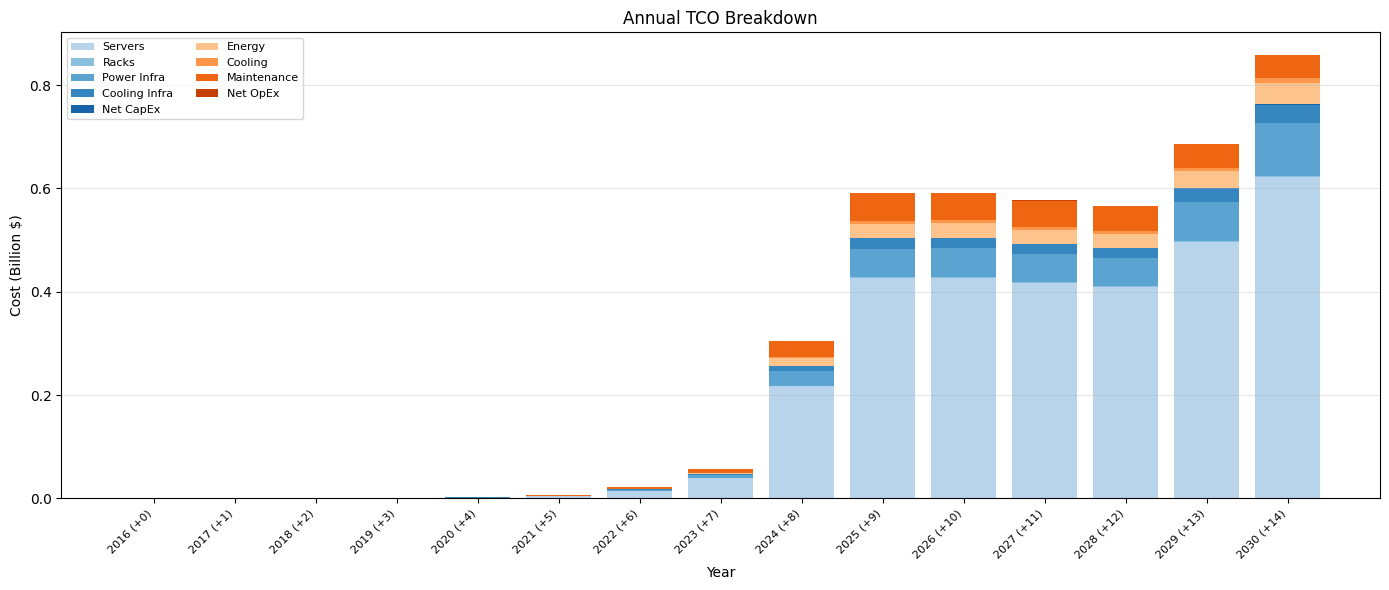

In [5]:
fig = plot_tco_breakdown(result)

## Server Fleet Composition

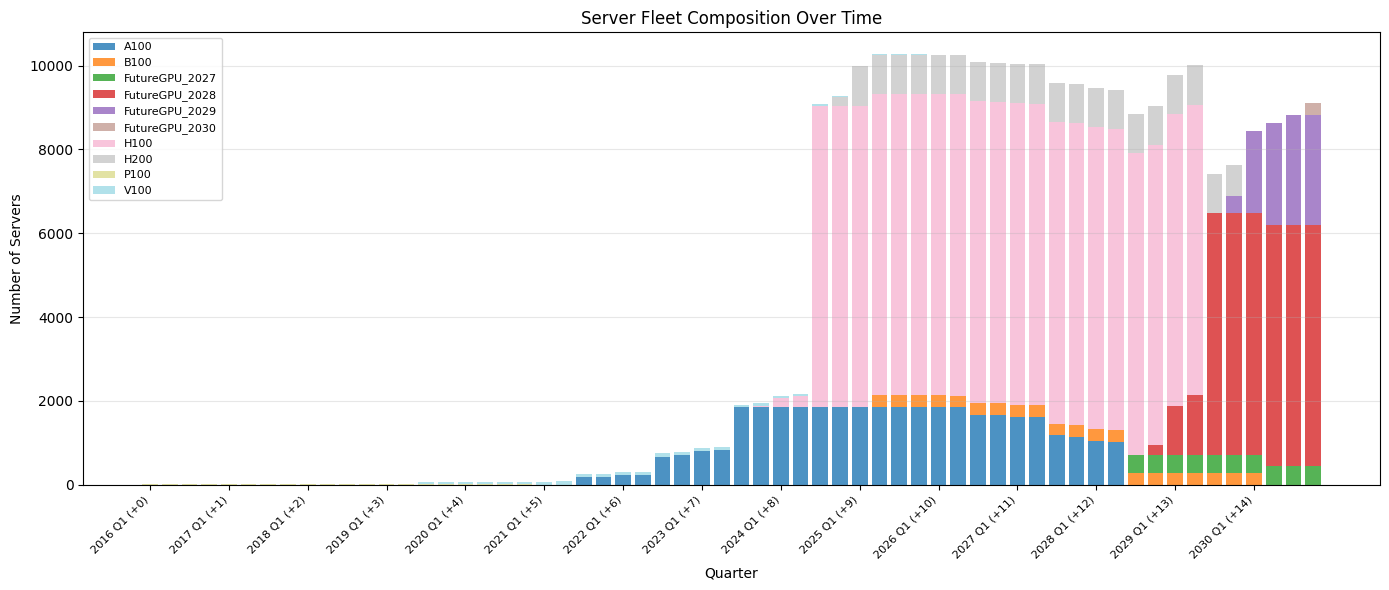

In [6]:
fig = plot_server_timeline(result)

## Demand vs Capacity

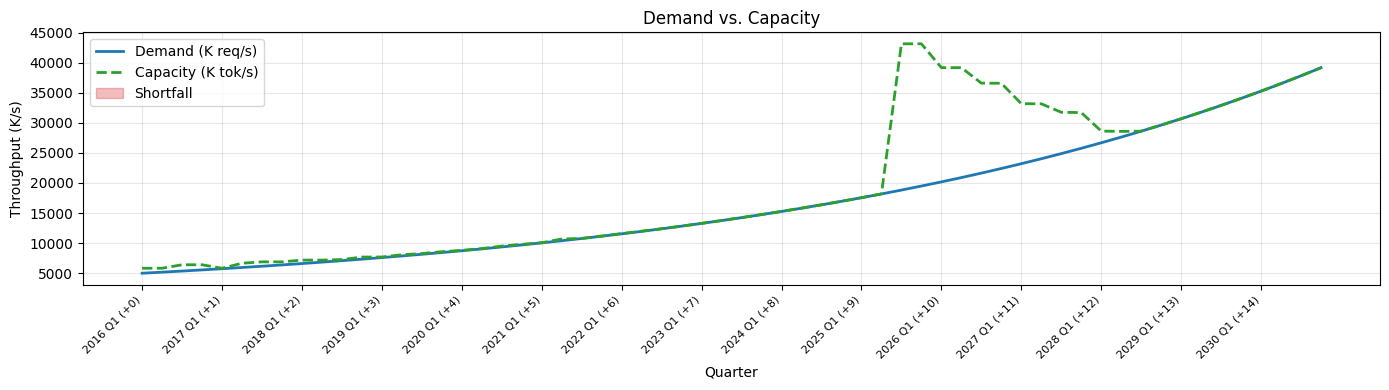

In [7]:
fig = plot_demand_curve(result)

## Stranded Power

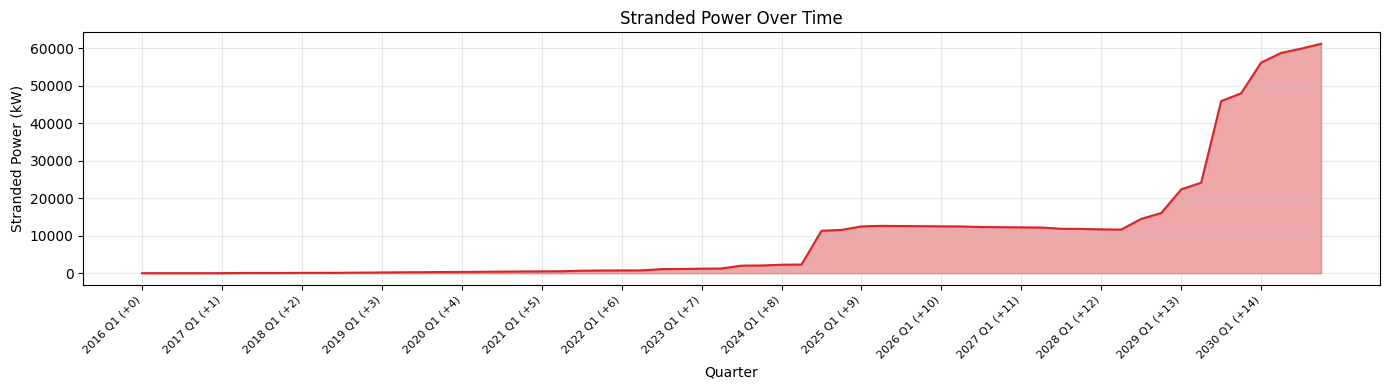

In [8]:
fig = plot_stranded_power(result)

## Detailed Batch Information

In [9]:
import pandas as pd

rows = []
for b in result.all_batches:
    rows.append({
        'batch_id': b.batch_id,
        'gpu': b.server.code_name,
        'start_q': b.start_q,
        'decom_q': b.decom_q,
        'servers': b.num_servers,
        'racks': b.num_racks,
        'server_tdp_w': b.server.tdp,
        'server_cost': b.server.cost,
    })

pd.DataFrame(rows)

,batch_id,gpu,start_q,decom_q,servers,racks,server_tdp_w,server_cost
0,0,P100,0,20,7,1,4800.000000,75424.000000
1,1,P100,5,25,1,1,4800.000000,75424.000000
2,2,V100,8,28,1,1,4000.000000,91664.000000
3,3,V100,10,30,10,1,4000.000000,91664.000000
4,4,V100,11,31,1,1,4000.000000,91664.000000
5,5,V100,12,32,2,1,4000.000000,91664.000000
6,6,V100,13,33,1,1,4000.000000,91664.000000
7,7,V100,14,34,31,3,4000.000000,91664.000000
8,8,V100,15,35,2,1,4000.000000,91664.000000
9,9,V100,16,36,7,1,4000.000000,91664.000000
